![Logo UOC](https://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/logotips/logo-UOC-2linies.png)

# TFG - Inteligencia Artificial
Enero de 2026

## Predicción de Respuesta a Tratamientos Oncológicos Basada en el Perfil Genético Mediante Técnicas de Aprendizaje Automático (ML) e Identificación de Genes Candidatos a Biomarcador Usando Técnicas de Explicabilidad (XAI) y Cuantificación de la Incertidumbre (UQ)

---

#### Pablo Vázquez Rodríguez
##### Grado en Ingeniería Informática
##### Inteligencia Artificial

#### Dra. María Moreno de Castro
#### Dr. Friman Sánchez

---

## Análisis de explicabilidad

Ahora se realizarán una serie de tareas con el foco puesto en explicar en qué se basa nuestro modelo óptimo para tomar las decisiones de clasificación. Para ello se han técnicas globales y locales que permitan explicar las decisiones y evaluar posibles genes candidatos a biomarcador.

Además, en cada paso se hará remuestreo con reemplazo (Bootstrap) [https://es.wikipedia.org/wiki/Bootstrapping_(estad%C3%ADstica)] tanto en cada apartado como al final, para visualizar la robustez estadística de cada conclusión de explicabilidad.

Se muestra a continuación la serie de pasos que se darán y el objetivo concreto, tanto de la técnica de XAI como del remuestreo.

1. **SHAP summary/global**
   * Ranking inicial de genes con dirección del efecto.
   * *Bootstrap*: Comprobar la estabilidad del ranking obtenido.
1. **Permutation feature importance**
    * Validar impacto real de cada gen en la métrica del modelo.
    * *Bootstrap*: Cuantificar la variabilidad de rendimiento en la métrica de referencia (F1).
1. **SHAP interaction values**
    * Detectar pares de genes con efectos combinados relevantes.
    * *Bootstrap*: Confirmar si los mismos pares aparecen de forma consistente.
1. **SHAP instance values**
    * Explicar casos individuales (respondedores, no respondedores, frontera).
    * *Bootstrap*: Verificar si las contribuciones locales se mantienen en distintas remuestras.
1. **DiCE contrafactuales**
    * Generar escenarios alternativos para identificar genes “palanca”.
    * *Bootstrap*: Medir la sensibilidad de los genes que actúan como palancas en contrafactuales repetidos.
1. **Bootstrap final de cierre**
    * Consolidar todo el pipeline y validar robustez global.
    * *Bootstrap*: Calcular presencia en top‑k y estabilidad de pares en remuestreo.

## 0. Operaciones previas

### Carga de módulos necesarios

In [43]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
import shap
import dice_ml
from aux_functions import dice_aux
from dice_ml import Dice
from collections import Counter
from functools import partial
from sklearn.model_selection import FixedThresholdClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from sklearn.metrics import f1_score, average_precision_score
from sklearn.inspection import permutation_importance

### Configuraciones iniciales

In [2]:
# Random generator de numpy con seed para reproducibilidad en el notebook
rng_seed = 19293
rng = np.random.default_rng(seed=rng_seed)

In [3]:
# Carga de los datasets
df_full = pd.read_csv("./data/final/full_top_significance_reduced_feat.csv")
df_train = pd.read_csv("./data/final/train_reduced_feat.csv")
df_test = pd.read_csv("./data/final/test_reduced_feat.csv")
df_cal = pd.read_csv("./data/final/cal_reduced_feat.csv")
df_scaled_train = pd.read_csv("./data/final/scaled_train_reduced_feat.csv")
df_scaled_test = pd.read_csv("./data/final/scaled_test_reduced_feat.csv")
df_scaled_cal = pd.read_csv("./data/final/scaled_cal_reduced_feat.csv")

In [4]:
# Carga del modelo óptimo
catboost_model = joblib.load("./data/best_models/best_catboost_model.joblib")

# Modelo optimo con threshold incluido
thresholded_catboost_model = FixedThresholdClassifier(
    catboost_model, threshold=0.19, response_method="predict_proba")

In [5]:
# VARIABLES ÚTILES

# Nombres de las columnas de genes
gene_columns = df_full.columns.difference(["Sample_id", "Response"])

In [6]:
# Datos de test
X_test = df_scaled_test.drop(columns=["Response", "Sample_id"])
y_test_orig = df_scaled_test["Response"]

# Clases objetivo a 0/1: Non_response=0, Response=1
le = LabelEncoder().fit(["Non_response", "Response"])
y_test = le.fit_transform(y_test_orig)

# Mostrar mapeo de clases
for i, label in enumerate(le.classes_): print(f"{i}: {label}")

0: Non_response
1: Response


### 1. SHAP summary/global

**Objetivo**: Ranking inicial de genes con dirección del efecto.

*Bootstrap*: Comprobar la estabilidad del ranking obtenido.

SHAP (SHapley Additive exPlanations) se basa en la teoría de los valores de Shapley, que distribuyen de manera justa la “contribución” de cada variable a la predicción de un modelo. [https://es.wikipedia.org/wiki/SHAP]

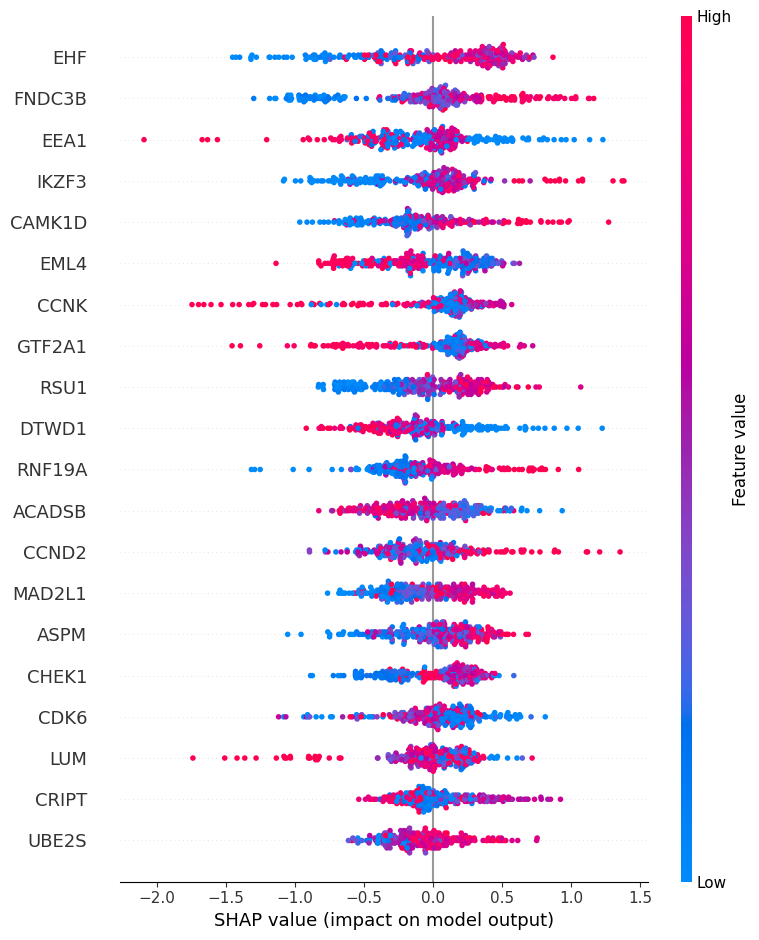

Top 10 genes según SHAP:


Index(['EHF', 'FNDC3B', 'EEA1', 'IKZF3', 'CAMK1D', 'EML4', 'CCNK', 'GTF2A1',
       'RSU1', 'DTWD1'],
      dtype='object')

In [7]:
# Calcular SHAP en todo el dataset de test
explainer = shap.TreeExplainer(catboost_model)
shap_values = explainer.shap_values(X_test)

# Beeswarm plot global
shap.summary_plot(shap_values, X_test, plot_type="dot")

# Top 10 genes según SHAP (para que sea más sencillo leer una lista y 
# comparar con la tabla bootstrap
mean_abs_shap = np.abs(shap_values).mean(axis=0)
ranking_idx = np.argsort(mean_abs_shap)[::-1]  # orden descendente
top10_features = X_test.columns[ranking_idx[:10]]

print("Top 10 genes según SHAP:")
top10_features

Para evaluar la estabilidad del ranking obtenido 

In [8]:
# Bootstrap: Comprobar la estabilidad del ranking obtenido
n_boot = 100
genes = X_test.columns
shap_boot = pd.DataFrame(index=genes, columns=range(n_boot))

for i in range(n_boot):
    # Remuestreo con reemplazo
    # OJO!! Aquí se pone el random_state=i en lugar de random_state=rng_seed, 
    #       porque si no cada iteración generaría el mismo resample!
    X_res = resample(X_test, replace=True, n_samples=len(X_test), random_state=i)
    shap_res = explainer.shap_values(X_res)
    
    # Guardar la media de |SHAP| por gen en esta muestra de datos
    shap_boot[i] = np.abs(shap_res).mean(axis=0)

# Calcular y mostrar estadísticas globales
shap_stats = pd.DataFrame({
    "mean_abs_shap": shap_boot.mean(axis=1),
    "std_abs_shap": shap_boot.std(axis=1)
}).sort_values("mean_abs_shap", ascending=False)

# Mostrar top 10
shap_stats.head(10)

,mean_abs_shap,std_abs_shap
EHF,0.426175,0.014559
FNDC3B,0.379585,0.023270
EEA1,0.319870,0.016214
IKZF3,0.305741,0.018183
CAMK1D,0.303461,0.014032
EML4,0.297757,0.011998
CCNK,0.295282,0.018938
GTF2A1,0.291907,0.013380
RSU1,0.289801,0.011922
DTWD1,0.278333,0.013139


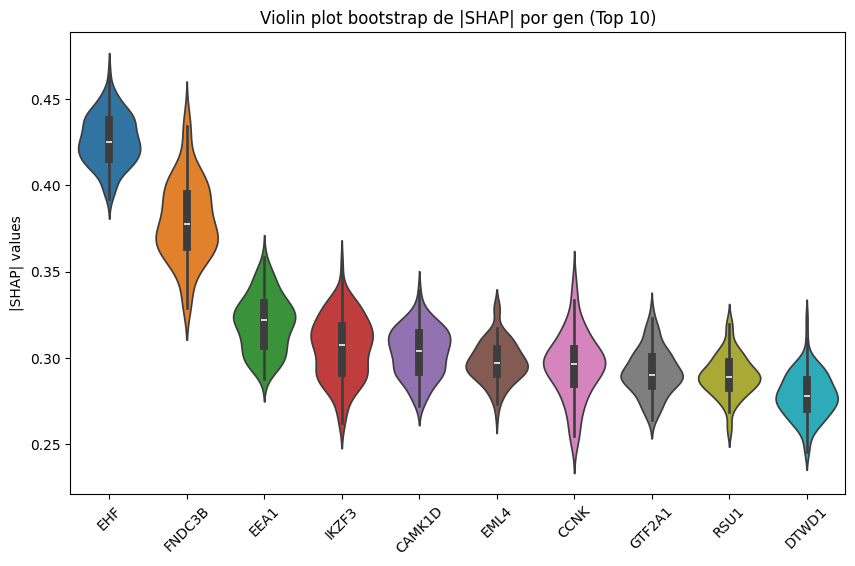

In [9]:
# Violin plot de |SHAP| por gen
top_genes = shap_stats.head(10).index

plt.figure(figsize=(10,6))
sns.violinplot(data=shap_boot.loc[top_genes].T)
plt.xticks(rotation=45)
plt.ylabel("|SHAP| values")
plt.title("Violin plot bootstrap de |SHAP| por gen (Top 10)")
plt.show()

El análisis global con SHAP nos permite identificar un conjunto de genes que destacan de forma consistente en la predicción. En el beeswarm, genes como EHF y FNDC3B aparecen claramente en la parte superior, reflejando una contribución elevada y sostenida. Este resultado se confirma en el bootstrapping, donde EHF alcanza una media de ∣SHAP∣ de 0.426 con una desviación estándar muy baja (0.015), lo que indica que su influencia se mantiene estable en prácticamente todas las réplicas. FNDC3B y EEA1 siguen la misma tendencia, reforzando la robustez del ranking inicial.

En cuanto a la forma del beeswarm, las colas largas y los acúmulos de puntos de distintos colores (rojo y azul mezclados) reflejan que los genes no tienen un efecto uniforme: valores altos y bajos de la misma variable pueden empujar la predicción en direcciones distintas según el contexto de otras características. Esto es típico en datos biológicos, donde la interacción entre genes y condiciones clínicas genera efectos heterogéneos. La ausencia de una separación clara entre colores indica que no hay un único patrón determinista, sino una distribución amplia de contribuciones que el modelo captura.

En conjunto, la coincidencia entre el ranking del beeswarm y la estabilidad estadística del bootstrap nos da confianza en que estos diez genes, con EHF y FNDC3B a la cabeza, son candidatos de interés, y confirman que su influencia en la predicción se mantiene robusta frente a la variabilidad del muestreo.

### 2. Permutation feature importance

**Objetivo**: Validar impacto real de cada gen en la métrica del modelo.

*Bootstrap*: Cuantificar la variabilidad de rendimiento en la métrica de referencia (F1).

Permutation importance mide cuánto cae la métrica del modelo (F1) cuando se permuta aleatoriamente una feature, rompiendo su relación con la variable objetivo.

In [10]:
# Función auxiliar para pasarle a permutation_importance
# Calcula la métrica f1 ajustada al umbral óptimo para
# el modelo óptimo con catboost
catboost_threshold = 0.19
def catboost_f1_with_threshold(model, X, y):
    # Umbral precalculado para el modelo óptimo
    # con CatBoost
    threshold = catboost_threshold
    y_proba = catboost_model.predict_proba(X)[:,1]
    # Predicción teniendo en cuenta el umbral que 
    # maximiza F1 en este modelo
    y_pred = (y_proba >= threshold).astype(int)
    return f1_score(y_test, y_pred)

In [11]:
# Calcular permutation feature importance
permutation_results = permutation_importance(
    catboost_model, X_test, y_test,
    scoring=catboost_f1_with_threshold,
    n_repeats=50, random_state=rng_seed
)

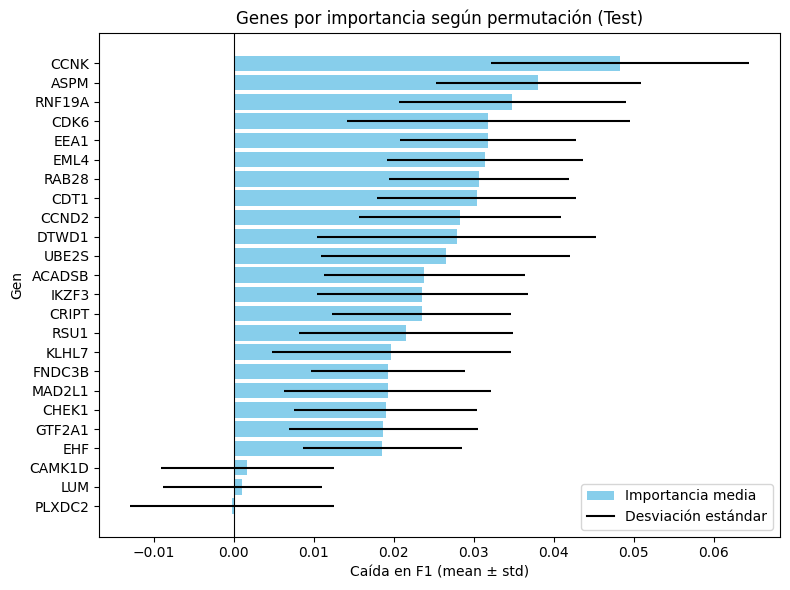

In [12]:
# Ordenar por importancia media
idx = np.argsort(permutation_results.importances_mean)[::-1]

plt.figure(figsize=(8,6))
bars = plt.barh(
    np.array(gene_columns)[idx],
    permutation_results.importances_mean[idx],
    xerr=permutation_results.importances_std[idx],
    color="skyblue",
    label="Importancia media"
)

# Hack para mostrar en la leyenda el significado de la 
# linea negra 
error_proxy = mlines.Line2D([], [], color="black", label="Desviación estándar")

plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Caída en F1 (mean ± std)")
plt.ylabel("Gen")
plt.title("Genes por importancia según permutación (Test)")
plt.gca().invert_yaxis()
plt.legend(handles=[bars, error_proxy], loc="lower right")
plt.tight_layout()
plt.show()

Una barra azul muy larga significa mayor contribución del gen al modelo, porque al desordenarlo el modelo pierde más capacidad para clasificar (según la métrica de referencia, F1). Por eso se dice que es la medida de la "importancia media", del gen en este caso.

La línea negra es la desviación estándar de la importancia media, es decir, la variabilidad de la caída de F1. Si la linea es corta es un efecto de la caída es estable, si es larga el efecto de la caída es más variable.

In [13]:
# Construir tabla ordenada con los resultados de las permutaciónes
summary = pd.DataFrame({
    "feature": X_test.columns,
    "mean_drop_F1": permutation_results.importances_mean,
    "std_drop_F1": permutation_results.importances_std
}).sort_values("mean_drop_F1", ascending=False)

# Mostrar las primeras filas (ej. top 10)
print("Original: Permutation Feature Importance")
summary.head(10)

Original: Permutation Feature Importance


,feature,mean_drop_F1,std_drop_F1
4,FNDC3B,0.048253,0.016140
1,IKZF3,0.038070,0.012842
21,CDK6,0.034813,0.014177
5,EHF,0.031818,0.017742
10,RNF19A,0.031779,0.011007
12,MAD2L1,0.031379,0.012273
20,PLXDC2,0.030615,0.011234
6,RSU1,0.030362,0.012432
3,CAMK1D,0.028304,0.012612
9,CCND2,0.027827,0.017384


Ahora se aplica bootstrap estratificado, porque usamos F1 y como permutation_importance es más pesado, se deja n_boot a 10, para que el proceso sea más ágil. Por esa razón, los efectos del desbalanceo podrían no suavizarse suficiente e incluir ruido estadístico.

In [14]:
# NOTA: Esta celda tarda varios minutos en ejecutarse 
#       (bajar n_boot si se quiere más presteza)

# Bootstrap: Cuantificar la variabilidad de rendimiento en la métrica de referencia (F1)
n_boot = 10
genes = X_test.columns

# DataFrame para guardar resultados bootstrap
permutation_boot = pd.DataFrame(index=genes, columns=range(n_boot))

for i in range(n_boot):
    # Remuestreo con reemplazo
    # OJO!! Aquí se pone el random_state=i en lugar de random_state=rng_seed, 
    #       porque si no cada iteración generaría el mismo resample!
    X_res, y_res = resample(X_test, y_test, replace=True, n_samples=len(X_test), 
                            stratify=y_test, random_state=i)
    perm_results = permutation_importance(
        catboost_model, X_res, y_res, scoring=catboost_f1_with_threshold,
        n_repeats=50, random_state=i)

    # Guardar importances_mean por gen en esta réplica
    permutation_boot[i] = perm_results.importances_mean

In [15]:
# Calcular y mostrar estadísticas globales (media y desviación estándar)
permutation_boot_results = pd.DataFrame({
    "mean_drop_F1": permutation_boot.mean(axis=1),
    "std_drop_F1": permutation_boot.std(axis=1)
}).sort_values("mean_drop_F1", ascending=False)

# Mostrar top 10
print("Bootstrap: Permutation Feature Importance")
permutation_boot_results.head(10)

Bootstrap: Permutation Feature Importance


,mean_drop_F1,std_drop_F1
CDK6,0.018567,0.018382
CCND2,0.014737,0.020911
KLHL7,0.014618,0.015802
ACADSB,0.014023,0.017090
EHF,0.011932,0.023093
DTWD1,0.006967,0.018755
EEA1,0.002812,0.012369
PLXDC2,0.000861,0.014206
EML4,-0.003070,0.015141
ASPM,-0.003985,0.015687


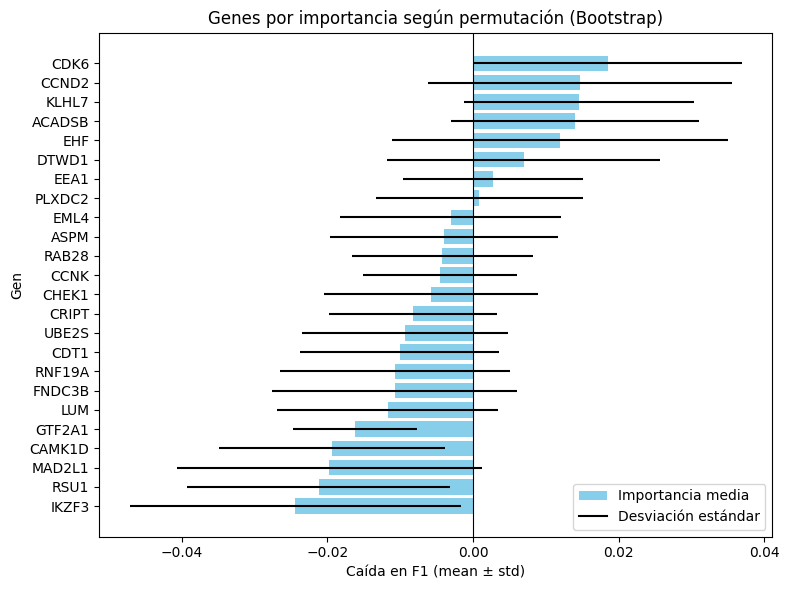

In [16]:
# Ordenar por importancia media
plt.figure(figsize=(8,6))
bars = plt.barh(
    permutation_boot_results.index,
    permutation_boot_results["mean_drop_F1"],
    xerr=permutation_boot_results["std_drop_F1"],
    color="skyblue",
    label="Importancia media"
)

# Hack para mostrar en la leyenda el significado de la 
# linea negra 
error_proxy = mlines.Line2D([], [], color="black", label="Desviación estándar")

plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Caída en F1 (mean ± std)")
plt.ylabel("Gen")
plt.title("Genes por importancia según permutación (Bootstrap)")
plt.gca().invert_yaxis()
plt.legend(handles=[bars, error_proxy], loc="lower right")
plt.tight_layout()
plt.show()

**Conclusiones extraídas**

Los resultados obtenidos muestran una discrepancia notable entre la estimación puntual de la importancia por permutación en el conjunto de prueba y la evaluación mediante remuestreo bootstrap. En el test, varios genes como FNDC3B, IKZF3 y CDK6 exhiben caídas claras en la métrica F1 al ser permutados, lo que sugiere que el modelo depende de ellos para mantener su rendimiento predictivo. Sin embargo, al aplicar bootstrap, las medias de caída en F1 se reducen drásticamente y las desviaciones estándar se incrementan, indicando que la relevancia de estos genes no se sostiene de manera robusta cuando se consideran múltiples réplicas del conjunto de datos. Esta diferencia pone de manifiesto la sensibilidad del análisis de importancia a la muestra concreta utilizada y la necesidad de validar los hallazgos con técnicas que capturen la variabilidad poblacional.

En términos interpretativos, los genes con medias cercanas a cero y desviaciones elevadas en el bootstrap, como PLXDC2, EEA1 o CCNK, deben considerarse candidatos espurios, ya que su aparente relevancia en el test no se reproduce de forma consistente en réplicas alternativas. Por el contrario, genes como CDK6 o EHF, que aparecen en ambos análisis aunque con menor magnitud en el bootstrap, podrían representar señales genuinas pero débiles, cuya importancia requiere confirmación adicional mediante validación cruzada o intervalos de confianza. En conjunto, los datos sugieren que el ranking derivado del test debe interpretarse con cautela y que la combinación de permutation importance con bootstrap es esencial para discriminar entre verdaderos determinantes del rendimiento y asociaciones espurias dependientes de la muestra.

### 3. SHAP interaction values

**Objetivo**: Detectar pares de genes con efectos combinados relevantes.

*Bootstrap*: Confirmar si los mismos pares aparecen de forma consistente.

Los SHAP interaction values consisten en descomponer la contribución de cada par de características en un modelo, separando el efecto propio de cada característica y el efecto combinado de su interacción sobre la predicción.

**NOTA**: En este caso hacemos directamente el análisis con bootstrap para identificar pares de genes que puedan mostrar algún efecto conjunto sobre la predicción.

In [17]:
# Detectar efectos combinados entre pares de genes y 
# confirmar si los mismos pares aparecen de forma consistente
n_boot=100

explainer = shap.TreeExplainer(catboost_model)
genes = X_test.columns
n_features = X_test.shape[1]

# Se han de guardar las matrices (n_features x n_features) por réplica
matrices = []
for i in range(n_boot):
    # Remuestreo con reemplazo (estratificado)
    # OJO!! Aquí se pone el random_state=i en lugar de random_state=rng_seed, 
    #       porque si no cada iteración generaría el mismo resample!
    X_res, y_res = resample(X_test, y_test, replace=True, n_samples=len(X_test), 
                            stratify=y_test, random_state=i)
    interaction_values_res = explainer.shap_interaction_values(X_res)
    # Matriz cuadrada de la media de valores absolutos
    # de interacción gen con gen
    gen_pair_interaction_matrix = np.abs(interaction_values_res).mean(axis=0)
    matrices.append(gen_pair_interaction_matrix)

# Aquí están todas las matrices de valores gen x gen para cada réplica
# del remuestreo. Es decir, se acaba con un array de 3 dimensiones
matrices = np.stack(matrices, axis=0)

# Aquí se procesan todas las matrices para aplanarlas en una sola matriz
# de medias y una sola matriz de desviaciones estándar
mean_matrix = matrices.mean(axis=0)
std_matrix  = matrices.std(axis=0, ddof=1)

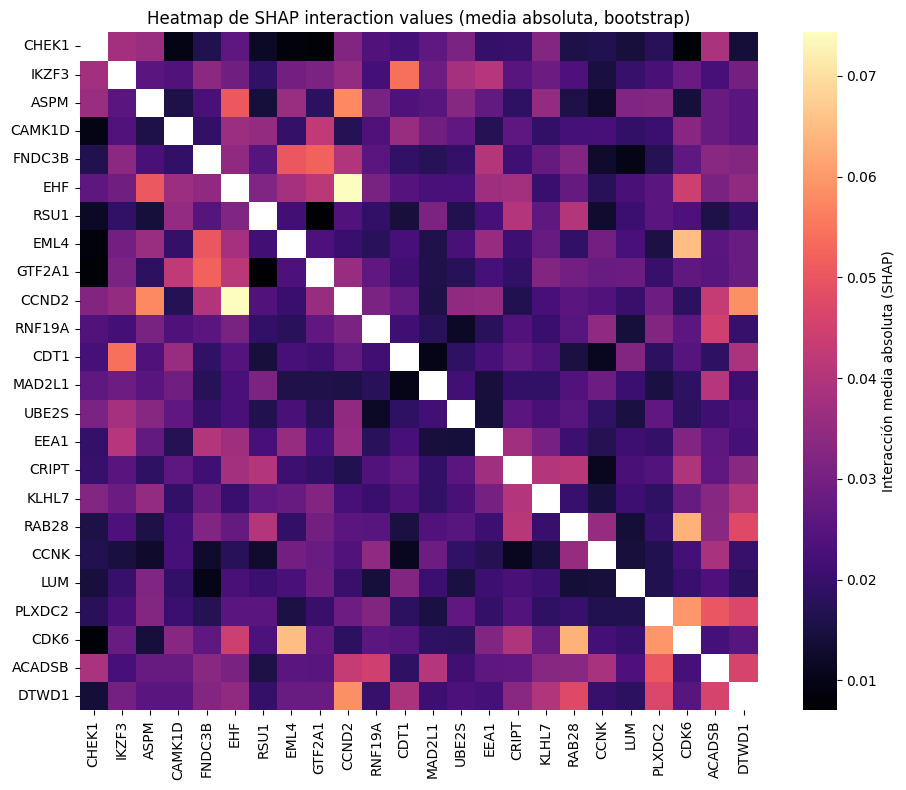

In [18]:
# Heatmap de interacciones promedio gen x gen

# OJO!: La diagonal contiene los enfrentamientos de un gen consigo mismo
#       en lugar de contener el valor de interacción, que siempre sería total,
#       se indica la contribución del gen al valor de la predicción del modelo 
#       respecto a la expectativa base.
#
#       Eso lo hace así SHAP interaction values, para mostrar información útil
#       Por esa razón se pone a cero la diagonal, ya que si no, subiría tanto 
#       la escala del gráfico que ocultaría los verdaderos efectos relativos
#       de interacción
mean_matrix_no_diagonal = mean_matrix.copy()
np.fill_diagonal(mean_matrix_no_diagonal, np.nan)

plt.figure(figsize=(10,8))
sns.heatmap(
    mean_matrix_no_diagonal,
    xticklabels=X_test.columns,
    yticklabels=X_test.columns,
    cmap="magma",
    square=True,
    cbar_kws={"label": "Interacción media absoluta (SHAP)"},
)
plt.title("Heatmap de SHAP interaction values (media absoluta, bootstrap)")
plt.tight_layout()
plt.show()

La diagonal contiene los enfrentamientos de un gen consigo mismo en lugar de contener el valor de interacción, que siempre sería total, se indica la contribución del gen al valor de la predicción del modelo respecto a la expectativa base.

Eso lo hace así SHAP interaction values, para mostrar información útil

In [19]:
# Tabla del top 10 de pares de genes con desviación
rows = []
for i in range(n_features):
    for j in range(i + 1, n_features):
        rows.append({
            "gene_i": genes[i],
            "gene_j": genes[j],
            "mean_abs_interaction": mean_matrix[i, j],
            "std_abs_interaction": std_matrix[i, j]
        })
df_pairs = pd.DataFrame(rows).sort_values("mean_abs_interaction", ascending=False)
top10 = df_pairs.head(10)
top10

,gene_i,gene_j,mean_abs_interaction,std_abs_interaction
108,EHF,CCND2,0.074331,0.003614
153,EML4,CDK6,0.064883,0.003166
258,RAB28,CDK6,0.063545,0.002239
270,PLXDC2,CDK6,0.059416,0.002961
184,CCND2,DTWD1,0.058568,0.002343
51,ASPM,CCND2,0.057593,0.002223
32,IKZF3,CDT1,0.054179,0.002553
89,FNDC3B,GTF2A1,0.051986,0.003150
47,ASPM,EHF,0.050488,0.002374
88,FNDC3B,EML4,0.050317,0.002333


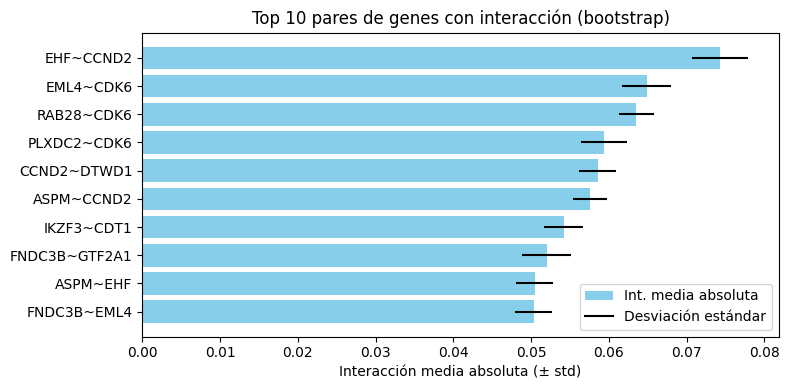

In [20]:
# Gráfico de barras con error para top 10
plt.figure(figsize=(8,4))

means = top10["mean_abs_interaction"].values
stds = top10["std_abs_interaction"].values

labels = [f"{r.gene_i}~{r.gene_j}" for _, r in top10.iterrows()]

# Hack para mostrar en la leyenda el significado de la 
# linea negra 
error_proxy = mlines.Line2D([], [], color="black", label="Desviación estándar")

bars = plt.barh(labels, means, xerr=stds, color="skyblue", label="Int. media absoluta")
plt.xlabel("Interacción media absoluta (± std)")
plt.title("Top 10 pares de genes con interacción (bootstrap)")
plt.gca().invert_yaxis()
plt.legend(handles=[bars, error_proxy], loc="lower right")
plt.tight_layout()
plt.show()

Los datos muestran que ciertos pares de genes, en particular EHF–CCND2 y varias combinaciones con CDK6 (EML4, RAB28, PLXDC2), alcanzan valores medios absolutos de interacción en torno a 0.06–0.07. Aunque en términos absolutos no son muy grandes, se consideran fuertes en el contexto del modelo porque representan el máximo rango observado en toda la distribución de interacciones. Al comparar con el resto de pares, que se sitúan por debajo de 0.05, estos valores destacan claramente como los más influyentes.

Además, la baja desviación estándar asociada (≈0.002–0.003) indica que estas interacciones son consistentes y reproducibles a lo largo de las réplicas bootstrap. Esa estabilidad es clave: no se trata de fluctuaciones aleatorias, sino de señales robustas que el modelo detecta de manera reiterada.

En el heatmap se aprecia claramente que los pares mencionados concentran la mayor parte de la señal de interacción. Esto confirma que, dentro de la escala interna del modelo, son los núcleos de interacción más relevantes.

En conclusión, los valores de 0.06–0.07 se interpretan como fuertes porque:
1. Son los máximos relativos en la distribución de interacciones.
1. Superan claramente al resto de pares, que tienen magnitudes menores.
1. Son estables en bootstrap, con desviaciones estándar muy bajas.

Por todo ello, los pares de ese top 10 merecen atención como posibles biomarcadores combinados.

### 4. SHAP instance values

**Objetivo**: Explicar casos individuales (respondedores, no respondedores, frontera).

*Bootstrap*: Verificar si las contribuciones locales se mantienen en distintas remuestras.

Los SHAP instance values muestran, para cada observación individual, cuánto contribuye cada variable a desplazar la predicción del modelo respecto a la media, indicando qué factores explican esa decisión concreta.

En este caso lo más interesante es estudiar casos extremos y casos frontera (aquellos cuya predicción está en el límite del umbral de probabilidad que lo haría clasificarse de la forma contraria).

Es por ello, que en este caso se seleccionarán 3 muestras de personas que han recibido tratamiento:
* La muestra con mayor probabilidad según el modelo (Respondedor más claro)
* La muestra con menor probabilidad según el modelo (No respondedor más claro)
* Una muestra con el la probabilidad más cercana al umbral de decisión (frontera)

In [21]:
# Se seleccionan pacientes más representativos

# Probabilidades de predicción
y_pred_proba = catboost_model.predict_proba(X_test)[:,1]

# Paciente frontera (probabilidad más cercana a 0.5)
patient_idx_border = np.argmin(np.abs(y_pred_proba - catboost_threshold))

# Paciente respondedor (positivo) más claro (probabilidad más alta)
patient_idx_pos = np.argmax(y_pred_proba)

# Paciente no respondedor (negativo) más claro (probabilidad más baja)
patient_idx_neg = np.argmin(y_pred_proba)

# Se construye el DataFrame con Sample_id, tipo y probabilidad
df_poi_patient = pd.DataFrame({
    "Index": [
        patient_idx_pos,
        patient_idx_neg,
        patient_idx_border
    ],
    "Sample_id": [
        df_scaled_test.iloc[patient_idx_pos]["Sample_id"],
        df_scaled_test.iloc[patient_idx_neg]["Sample_id"],
        df_scaled_test.iloc[patient_idx_border]["Sample_id"]
    ],
    "Tipo paciente": [
        "Positivo claro",
        "Negativo claro",
        "Frontera (umbral F1)"
    ],
    "Prob. Modelo": [
        y_pred_proba[patient_idx_pos],
        y_pred_proba[patient_idx_neg],
        y_pred_proba[patient_idx_border]
    ]
})

df_poi_patient

,Index,Sample_id,Tipo paciente,Prob. Modelo
0,225,GSM158222,Positivo claro,0.991014
1,5,GSM505587,Negativo claro,0.000311
2,273,GSM750745,Frontera (umbral F1),0.189971


In [22]:
# Función auxiliar para generar gráficos de waterfall
# en base a datos de paciente de interés (df_poi_patient)
def waterfall_plot(X, poi_patient_data):
    # Obtener datos del paciente
    idx, sample_id, patient_type, patient_prob = poi_patient_data
    x_patient = X.iloc[idx:idx+1]
    
    # Calcular SHAP values para el paciente
    shap_values_patient = explainer(x_patient)
    
    # Dibujar waterfall
    shap.plots.waterfall(shap_values_patient[0], show=False)
    plt.title(f"Paciente: {patient_type} ({sample_id})")

    plt.tight_layout()
    plt.show()

In [23]:
# Función auxiliar para tener los datos de SHAP values relevantes
def get_relevant_shap_data(X, poi_patient_data, decimals=2):
    # Obtener datos del paciente
    idx, sample_id, patient_type, patient_prob = poi_patient_data
    x_patient = X.iloc[idx:idx+1]
    
    # Extraer datos del paciente
    shap_values_patient = explainer(x_patient)
    
    # Obtener valor base y predicción final
    base_value = round(shap_values_patient.base_values[0], decimals)
    final_prediction = round(base_value + shap_values_patient.values[0].sum(), decimals)
    
    # Construir tabla con contribuciones
    df_waterfall = pd.DataFrame({
        "Gen": X.columns,
        "Valor": x_patient.values[0],
        "SHAP_value": shap_values_patient.values[0]
    }).sort_values("SHAP_value", key=np.abs, ascending=False)
    print(f"\nPaciente: {patient_type} ({sample_id})")
    print("\nValor base:", base_value)
    print("\nPredicción final:", final_prediction)
    # Devolver datos redondeados
    df_waterfall = df_waterfall.round(decimals)
    return df_waterfall

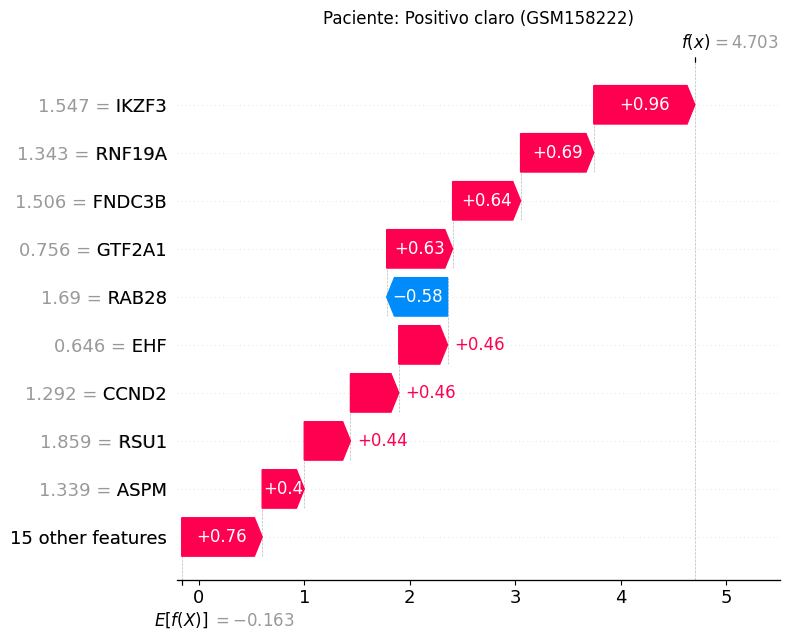

In [24]:
# Gráfico de paciente Positivo Claro
waterfall_plot(X_test, df_poi_patient.iloc[0])

In [25]:
# Datos de paciente Positivo Claro
# Top 10
get_relevant_shap_data(X_test, df_poi_patient.iloc[0]).head(10)


Paciente: Positivo claro (GSM158222)

Valor base: -0.16

Predicción final: 4.71


,Gen,Valor,SHAP_value
1,IKZF3,1.55,0.96
10,RNF19A,1.34,0.69
4,FNDC3B,1.51,0.64
8,GTF2A1,0.76,0.63
17,RAB28,1.69,-0.58
5,EHF,0.65,0.46
9,CCND2,1.29,0.46
6,RSU1,1.86,0.44
2,ASPM,1.34,0.40
3,CAMK1D,1.27,0.37


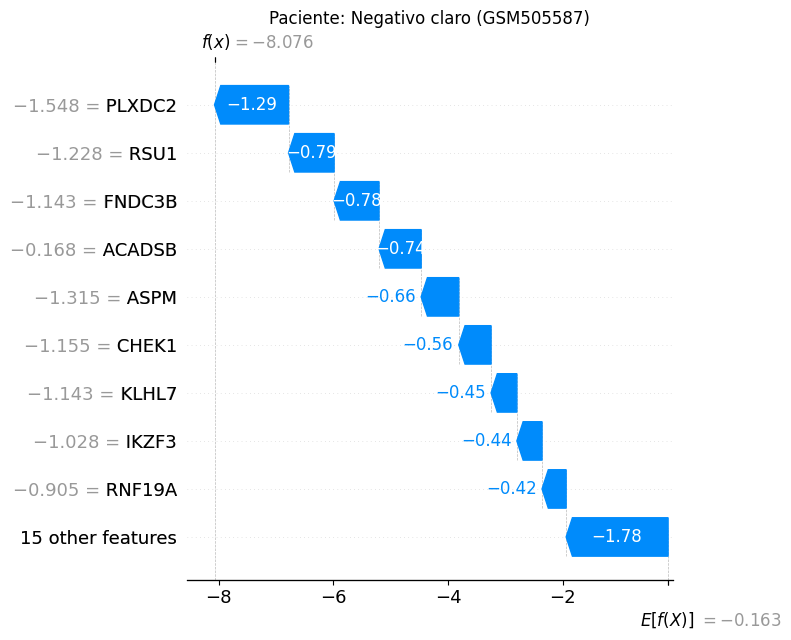

In [26]:
# Gráfico de paciente Negativo Claro
waterfall_plot(X_test, df_poi_patient.iloc[1])

In [27]:
# Datos de paciente Negativo Claro
# Top 10
get_relevant_shap_data(X_test, df_poi_patient.iloc[1]).head(10)


Paciente: Negativo claro (GSM505587)

Valor base: -0.16

Predicción final: -8.07


,Gen,Valor,SHAP_value
20,PLXDC2,-1.55,-1.29
6,RSU1,-1.23,-0.79
4,FNDC3B,-1.14,-0.78
22,ACADSB,-0.17,-0.74
2,ASPM,-1.32,-0.66
0,CHEK1,-1.16,-0.56
16,KLHL7,-1.14,-0.45
1,IKZF3,-1.03,-0.44
10,RNF19A,-0.90,-0.42
23,DTWD1,-1.05,-0.40


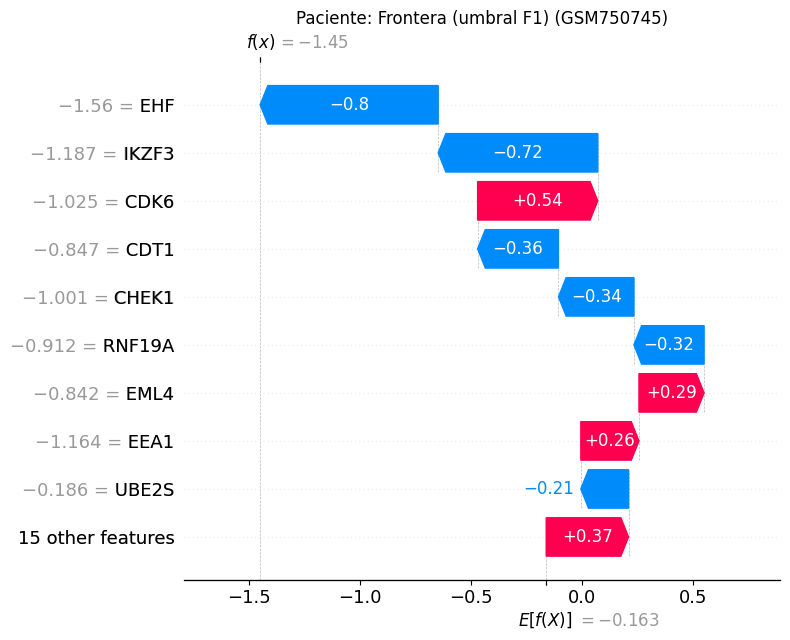

In [28]:
# Gráfico de paciente Frontera
waterfall_plot(X_test, df_poi_patient.iloc[2])

In [29]:
# Datos de paciente Frontera
# Top 10
get_relevant_shap_data(X_test, df_poi_patient.iloc[2]).head(10)


Paciente: Frontera (umbral F1) (GSM750745)

Valor base: -0.16

Predicción final: -1.45


,Gen,Valor,SHAP_value
5,EHF,-1.56,-0.80
1,IKZF3,-1.19,-0.72
21,CDK6,-1.03,0.54
11,CDT1,-0.85,-0.36
0,CHEK1,-1.00,-0.34
10,RNF19A,-0.91,-0.32
7,EML4,-0.84,0.29
14,EEA1,-1.16,0.26
13,UBE2S,-0.19,-0.21
18,CCNK,-1.22,0.20


In [30]:
# Función auxiliar para calcular las estadísticas de resampleo
def get_bootstrap_statistical_data(X, poi_patient_data, n_boot=100, decimals=2):
    # Obtener datos paciente
    idx, sample_id, patient_type, patient_prob = poi_patient_data
    x_patient = X.iloc[idx:idx+1]

    all_shap_values = []
    
    for i in range(n_boot):
        # Remuestreo con reemplazo
        # OJO!! Aquí se pone el random_state=i en lugar de random_state=rng_seed, 
        #       porque si no cada iteración generaría el mismo resample!
        X_res = resample(X, replace=True, n_samples=len(X), random_state=i)
    
        # NOTA: En este caso se inicializa un nuevo explainer en cada iteración, porque
        #       se está tratando con una sola muestra. Se ha de cambiar
        #       el background contra el que esa muestra (x_patient) se comparará.
        #       En el caso de SHAP summary/global, como era un cálculo global, SHAP
        #       calcula los valores para cada fila de X_res y las compara contra el valor
        #       esperado interno del modelo. En el caso local, como sólo le pasamos una 
        #       fila, hay que cambiar el background de comparación.
        explainer_res = shap.TreeExplainer(catboost_model, data=X_res)
        
        # Calcular SHAP values del paciente respecto a esta réplica
        shap_res = explainer_res.shap_values(x_patient)
        all_shap_values.append(shap_res[0])
    
    # Agrupar valores de todos los remuestreos
    all_shap_values = np.stack(all_shap_values, axis=0)
    
    # Calcular media y desviación estándar por gen
    mean_contrib = all_shap_values.mean(axis=0)
    std_contrib = all_shap_values.std(axis=0, ddof=1)

    # Construir dataframe y ordenar por media descendente
    df_stats = pd.DataFrame({
        "Gen": X_test.columns,
        "Mean_SHAP": mean_contrib,
        "Std_SHAP": std_contrib
    }).sort_values("Mean_SHAP", ascending=False)

    # Redondear y devolver
    df_stats = df_stats.round(decimals)

    return df_stats

In [31]:
# Estadísticas de resampleo: Paciente Positivo Claro
positive_patient_stats = get_bootstrap_statistical_data(X_test, df_poi_patient.iloc[0])

# Se muestra el top 10
positive_patient_stats.head(10)

,Gen,Mean_SHAP,Std_SHAP
1,IKZF3,1.20,0.07
4,FNDC3B,1.09,0.07
10,RNF19A,1.03,0.06
6,RSU1,0.89,0.07
5,EHF,0.64,0.08
3,CAMK1D,0.63,0.05
9,CCND2,0.58,0.05
12,MAD2L1,0.42,0.04
2,ASPM,0.36,0.03
0,CHEK1,0.28,0.04


In [32]:
# Función auxiliar para crear gráfico con bandas de incertidumbre
def make_bootstrap_statistical_data_graph(X, poi_patient_data, patient_stats):
    # Obtener datos paciente
    idx, sample_id, patient_type, patient_prob = poi_patient_data
    x_patient = X.iloc[idx:idx+1]
    
    # Visualización tipo waterfall con lineas de incertidumbre
    plt.figure(figsize=(8,6))
    bars = plt.barh(
        patient_stats["Gen"], 
        patient_stats["Mean_SHAP"], 
        xerr=patient_stats["Std_SHAP"], 
        color="skyblue",
        label="Contribución media local"
    )

    # Hack para mostrar en la leyenda el significado de la linea negra 
    error_proxy = mlines.Line2D([], [], color="black", label="Desviación estándar")
    
    plt.axvline(0, color="black", linewidth=0.8)
    plt.title(f"SHAP instance values | Paciente: {patient_type} ({sample_id})")
    plt.xlabel("Contribución media ± std")
    plt.ylabel("Gen")
    plt.gca().invert_yaxis()
    plt.legend(handles=[bars, error_proxy], loc="lower right")
    plt.tight_layout()
    plt.show()

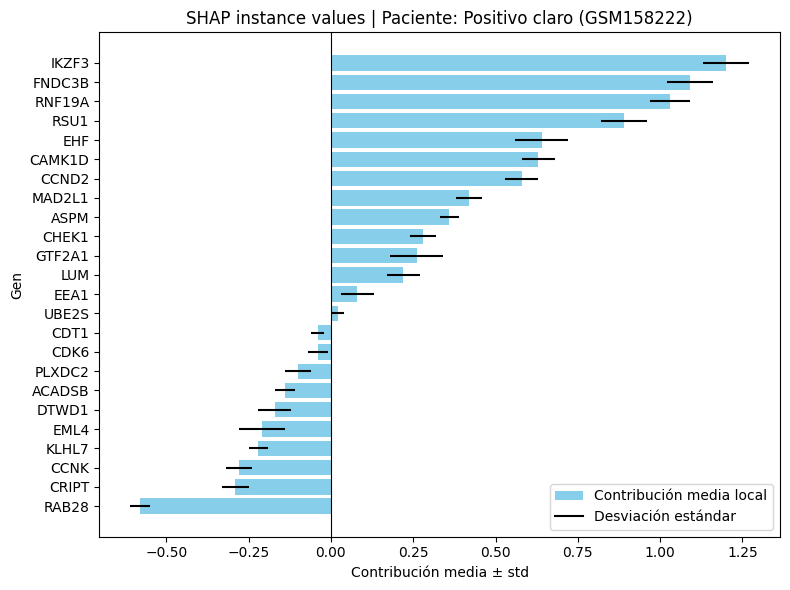

In [33]:
# Gráfico con bandas de incertidumbre tras remuestreo para evaluar robustez
# Paciente Positivo Claro
make_bootstrap_statistical_data_graph(X_test, df_poi_patient.iloc[0], positive_patient_stats)

In [34]:
# Estadísticas de resampleo: Paciente Negativo Claro
negative_patient_stats = get_bootstrap_statistical_data(X_test, df_poi_patient.iloc[1])

# Se muestra el top 10
negative_patient_stats.head(10)

,Gen,Mean_SHAP,Std_SHAP
7,EML4,0.23,0.06
8,GTF2A1,0.23,0.04
5,EHF,0.21,0.07
18,CCNK,0.16,0.04
17,RAB28,0.07,0.03
19,LUM,0.06,0.03
23,DTWD1,0.01,0.08
21,CDK6,-0.01,0.04
14,EEA1,-0.05,0.05
15,CRIPT,-0.19,0.04


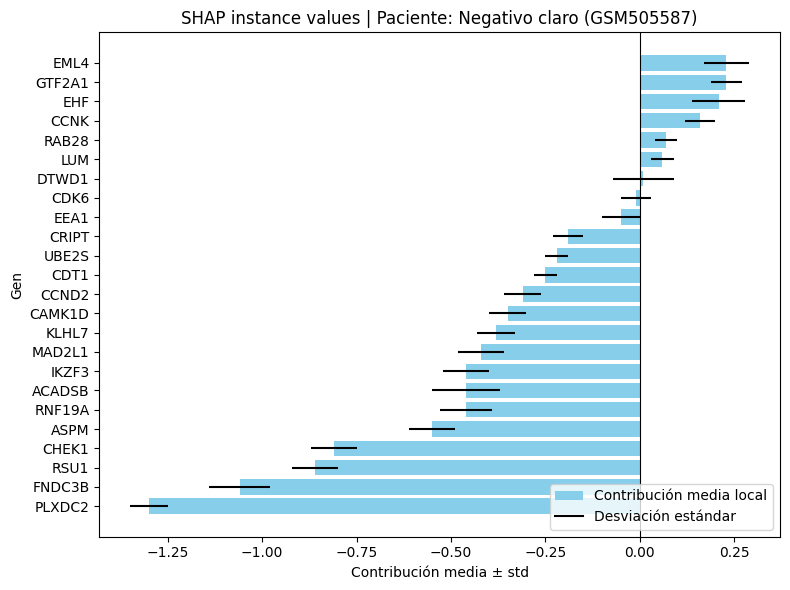

In [35]:
# Gráfico con bandas de incertidumbre tras remuestreo para evaluar robustez
# Paciente Negativo Claro
make_bootstrap_statistical_data_graph(X_test, df_poi_patient.iloc[1], negative_patient_stats)

In [36]:
# Estadísticas de resampleo: Paciente Frontera
borderline_patient_stats = get_bootstrap_statistical_data(X_test, df_poi_patient.iloc[2])

# Se muestra el top 10
borderline_patient_stats.head(10)

,Gen,Mean_SHAP,Std_SHAP
23,DTWD1,0.49,0.05
7,EML4,0.48,0.05
21,CDK6,0.43,0.04
14,EEA1,0.38,0.05
22,ACADSB,0.37,0.04
18,CCNK,0.35,0.06
17,RAB28,0.34,0.05
8,GTF2A1,0.26,0.04
16,KLHL7,0.26,0.04
15,CRIPT,-0.00,0.03


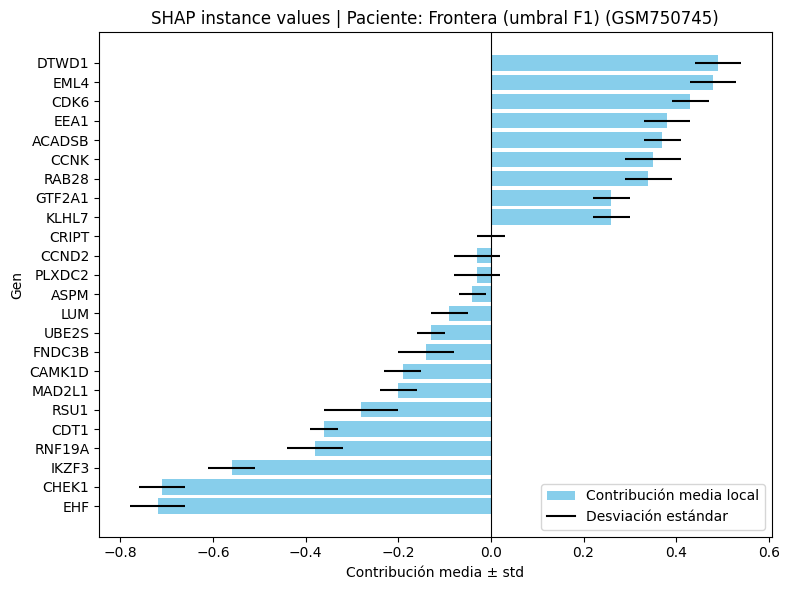

In [37]:
# Gráfico con bandas de incertidumbre tras remuestreo para evaluar robustez
# Paciente Frontera
make_bootstrap_statistical_data_graph(X_test, df_poi_patient.iloc[2], borderline_patient_stats)

**Conclusiones extraídas**

El análisis de las explicaciones locales mediante valores SHAP permitió identificar las variables más influyentes en tres pacientes representativos: uno con predicción positiva clara (GSM158222), otro con predicción negativa clara (GSM505587) y un caso frontera ajustado al umbral del modelo (GSM750745). La aplicación de bootstrap, recalculando las contribuciones locales en distintas remuestras, aportó información adicional sobre la estabilidad de dichas explicaciones.

En el paciente positivo (GSM158222), el waterfall inicial mostró contribuciones destacadas de genes como IKZF3 (0.96), RNF19A (0.69) y FNDC3B (0.64). Tras aplicar bootstrap, estas variables mantuvieron valores medios elevados (IKZF3: 1.20; FNDC3B: 1.09; RNF19A: 1.03) con desviaciones estándar reducidas (≈0.06–0.07), lo que confirma la robustez de su efecto positivo sobre la predicción. Este resultado sugiere que el modelo identifica de manera consistente un conjunto de genes clave en pacientes con alta probabilidad de pertenencia a la clase positiva.

En el paciente negativo (GSM505587), el waterfall reflejó contribuciones negativas dominantes, como PLXDC2 (-1.29), RSU1 (-0.79) y FNDC3B (-0.78). Sin embargo, tras el bootstrap las contribuciones medias se redujeron notablemente, con valores próximos a cero o incluso positivos en algunos casos (EML4: 0.23; GTF2A1: 0.23). Además, las desviaciones estándar fueron mayores en comparación con el paciente positivo, lo que indica una mayor variabilidad en las explicaciones. Este hallazgo sugiere que, aunque el modelo logra una predicción negativa clara, la explicación local es menos estable y depende en mayor medida del background utilizado.

En el paciente frontera (GSM750745), el waterfall inicial mostró efectos contrapuestos: genes como EHF (-0.80) e IKZF3 (-0.72) reducían la predicción, mientras que CDK6 (0.54) y EML4 (0.29) la incrementaban. Tras el bootstrap, las contribuciones medias se mantuvieron en valores intermedios (DTWD1: 0.49; EML4: 0.48; CDK6: 0.43), pero con desviaciones estándar moderadas (≈0.04–0.06), reflejando la sensibilidad del modelo en situaciones cercanas al umbral. Este comportamiento confirma que las explicaciones en casos frontera son más dependientes del contexto y presentan menor robustez que en los extremos.

En conjunto, los resultados muestran que las contribuciones clave se mantienen en cada paciente, especialmente en los casos extremos, donde las variables principales presentan efectos consistentes y estables. En cambio, en el paciente frontera se observa mayor variabilidad, lo que refleja la dificultad inherente del modelo para discriminar en situaciones ambiguas. Esta evidencia respalda la coherencia clínica de las explicaciones locales y asegura que la información global del modelo se refleja en las decisiones individuales, aunque con un grado de incertidumbre mayor en los casos límite.

### 5. DiCE contrafactuales

**Objetivo**: Generar escenarios alternativos para identificar genes “palanca”.

*Bootstrap*: Medir la sensibilidad de los genes que actúan como palancas en contrafactuales repetidos.

Definiciones:

* "Gen palanca": Genes que si se modifica ligeramente su valor hacen cambiar la decisión del modelo.

* "Contrafactual": Realidad alternativa plausible. Ej: Si el modelo predice Non_response (hecho), ¿qué tendría que cambio mínimo supondría decidir lo opuesto, Response? (contra-hecho)

DiCE consiste en un método de explicabilidad que genera contrafactuales diversos, es decir, ejemplos alternativos mínimos y plausibles que muestran qué cambios en las variables harían que la predicción del modelo cambiase de clase.

Los contrafactuales en casos frontera permiten identificar rutas de cambio plausibles y accionables, mientras que en los extremos sirven como control de robustez: revertir la clase exige modificaciones extensas, lo que confirma la estabilidad de las predicciones claras.

Por esa razón se usarán los 3 mismos pacientes del anterior análisis local al presente análisis.

La generación de contrafactuales con DiCE se lleva a cabo en distintas remuestras bootstrap directamente, para comprobar hasta qué punto las rutas de cambio propuestas son consistentes. Al repetir el proceso varias veces, se puede observar qué genes aparecen de manera recurrente como “palancas” capaces de modificar la clase del modelo. Esa repetición evita que las conclusiones dependan de una única ejecución y aporta una visión más sólida de las variables implicadas. En este contexto, la frecuencia con la que un gen emerge como palanca se interpreta como un indicador de su robustez y de su potencial relevancia clínica.

#### Justificación

Se ha ido pasando de lo global a lo local. Tras identificar genes relevantes a nivel global (SHAP summary/global), contrastar su estabilidad mediante permutation importance (Permutation feature importance), explorar interacciones consistentes (SHAP interaction values) y verificar explicaciones locales en pacientes representativos (SHAP instance values), el siguiente paso consiste en aplicar contrafactuales diversos con DiCE. 

Este análisis permite identificar genes que actúan como palancas de cambio en la clasificación del modelo. La aplicación de bootstrap asegura que dichas palancas no dependan de una única ejecución, sino que se repitan de manera consistente en múltiples escenarios. La frecuencia de aparición de cada gen como palanca se interpreta como un indicador de robustez y acciónabilidad clínica, y se contrasta con los hallazgos globales e interacciones previas para evaluar la coherencia entre niveles de explicabilidad.

En base a los análisis previos, y siguiendo algunas reglas intuitivas en base a los datos obtenidos en los pasos anteriores, seleccionamos algunos genes candidatos a palanca, para centrar el foco de DiCE y que así genere contrafactuales que estén relacionados con los genes de mayor interés según las experiencias anteriores

In [38]:
# Selección de genes más interesantes según cada paso o que pueden considerarse espurios
shap_global_top = ["EHF", "FNDC3B", "EEA1", "IKZF3", "CAMK1D", "EML4"]
perm_importance_robust = ["EHF", "CDK6", "FNDC3B"]                 # tras bootstrap
interactions_strong = ["EHF", "CCND2", "EML4", "RAB28", "CDK6"]    # socios de pares fuertes
local_consistent = ["IKZF3", "RNF19A", "EML4", "DTWD1", "CHEK1"]   # En pacientes extremos/frontera

# Reglas: incluir intersección fuerte + ampliación por interacción y local
candidate_set = set(shap_global_top) | set(perm_importance_robust) | set(interactions_strong) | set(local_consistent)

# Exclusiones por espuriedad en permutation/bootstrap o baja plausibilidad clínica
exclude_spurious = {"EEA1", "PLXDC2", "EML4", "ASPM", "RAB28", "CHEK1", "DTWD"}  # señal fue inestable

features_to_vary = sorted(list(candidate_set - exclude_spurious))
print("features_to_vary:", features_to_vary)

features_to_vary: ['CAMK1D', 'CCND2', 'CDK6', 'DTWD1', 'EHF', 'FNDC3B', 'IKZF3', 'RNF19A']


In [89]:
# Se preconfiguran algunas funciones auxiliares para hacer más simple la llamada
# Función parcialmente preconfigurada para calcular DiCE
calculate_dice_configured = partial(dice_aux.calculate_dice, gene_columns=gene_columns,
                                    model=thresholded_catboost_model, rng_seed=rng_seed)

# Función parcialmente preconfigurada para calcular DiCE con resampleo y mostrar histograma
calculate_dice_bootstrap_configured = partial(dice_aux.calculate_dice_bootsrap, gene_columns=gene_columns,
                                    model=thresholded_catboost_model, rng_seed=rng_seed)

In [79]:
# Cálculo de DiCe y gráfico de barras con genes palanca
# Paciente Positivo Claro
calculate_dice_configured(X_test, y_test, features_to_vary, df_poi_patient.iloc[0])

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.73it/s]

**Original** | Paciente: **Positivo claro** (GSM158222)

,CAMK1D,CCND2,CDK6,DTWD1,EHF,FNDC3B,IKZF3,RNF19A,Response
0,1.27,1.29,0.98,0.98,0.65,1.51,1.55,1.34,1.0


**Contrafactuales** | Paciente: **Positivo claro** (GSM158222)

,CAMK1D,CCND2,CDK6,DTWD1,EHF,FNDC3B,IKZF3,RNF19A,Response
0,-,-1.69,-,-,-,-1.97,-,-,0
1,-,-1.28,-,-,-,-,-,-1.21,0
2,-,-1.26,-,-,-,-,-,-1.19,0
3,-,-,-,-,-1.96,-1.82,-,-,0
4,-,-,-,-,-1.43,-,-,-0.94,0


In [80]:
# Cálculo de DiCe y gráfico de barras con genes palanca
# Paciente Negativo Claro
calculate_dice_configured(X_test, y_test, features_to_vary, df_poi_patient.iloc[1])

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.37it/s]

**Original** | Paciente: **Negativo claro** (GSM505587)

,CAMK1D,CCND2,CDK6,DTWD1,EHF,FNDC3B,IKZF3,RNF19A,Response
0,-0.98,-1.3,-0.98,-1.05,-0.57,-1.14,-1.03,-0.9,0.0


**Contrafactuales** | Paciente: **Negativo claro** (GSM505587)

,CAMK1D,CCND2,CDK6,DTWD1,EHF,FNDC3B,IKZF3,RNF19A,Response
0,-,2.21,-,-,1.47,1.56,3.36,1.59,1
1,1.55,-,2.22,-,-,1.29,2.99,1.36,1
2,1.68,-,-,-,-,1.4,3.14,1.45,1
3,1.81,-,-,-,-,1.53,-,1.56,1
4,1.64,-,-,-,-,1.37,-,1.43,1


In [81]:
# Cálculo de DiCe y gráfico de barras con genes palanca
# Paciente Frontera
calculate_dice_configured(X_test, y_test, features_to_vary, df_poi_patient.iloc[2])

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.83it/s]

**Original** | Paciente: **Frontera (umbral F1)** (GSM750745)

,CAMK1D,CCND2,CDK6,DTWD1,EHF,FNDC3B,IKZF3,RNF19A,Response
0,-0.96,0.1,-1.03,-1.24,-1.56,-0.43,-1.19,-0.91,0.0


**Contrafactuales** | Paciente: **Frontera (umbral F1)** (GSM750745)

,CAMK1D,CCND2,CDK6,DTWD1,EHF,FNDC3B,IKZF3,RNF19A,Response
0,-,-,-,-,-,1.34,-,-,1
1,-,-,-,-,-,-,1.82,0.6,1
2,1.92,-,-,-,-,-,3.45,-,1
3,1.42,-,-,-,-,-,-,-,1
4,-,-,-,-,-,-,3.49,-,1


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  5.15it/s]


Paciente: Positivo claro (GSM158222)

,Gen,Frequency
2,FNDC3B,108
0,CCND2,107
4,EHF,95
1,RNF19A,91
3,DTWD1,42
7,CAMK1D,32
5,IKZF3,17
6,CDK6,8


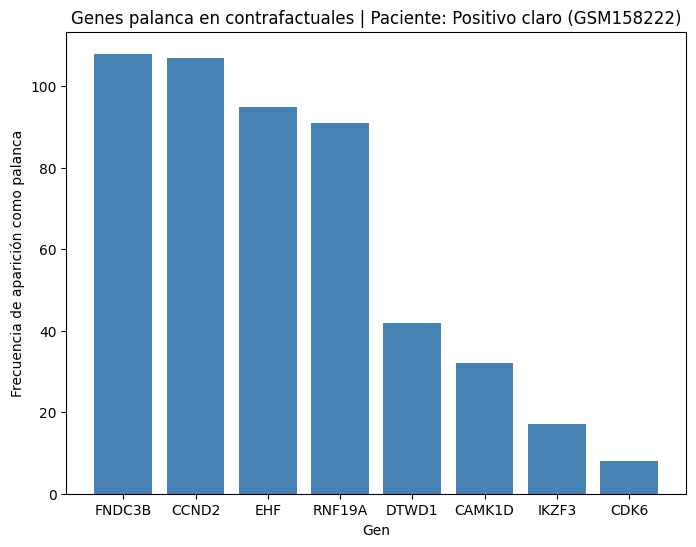

In [90]:
# Cálculo de DiCe y gráfico de barras con genes palanca
# Paciente Positivo Claro
calculate_dice_bootstrap_configured(X_test, y_test, features_to_vary, df_poi_patient.iloc[0])

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.93it/s]


Paciente: Negativo claro (GSM505587)

,Gen,Frequency
2,RNF19A,248
1,FNDC3B,243
3,CAMK1D,180
0,IKZF3,171
6,EHF,66
5,CCND2,37
4,CDK6,5
7,DTWD1,1


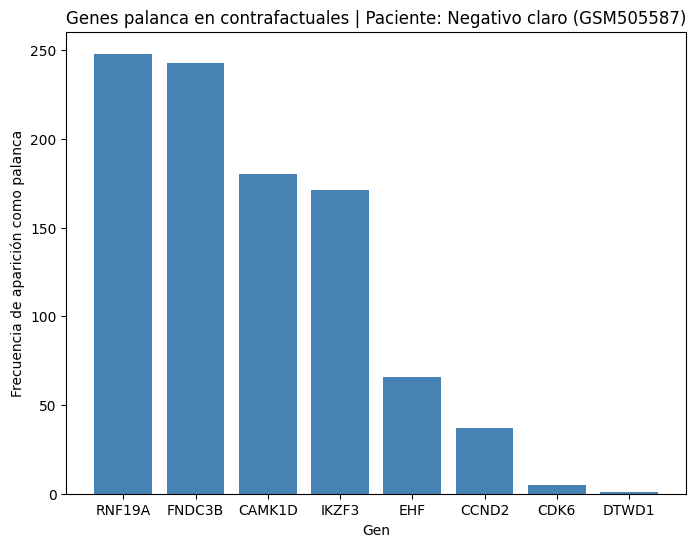

In [91]:
# Cálculo de DiCe y gráfico de barras con genes palanca
# Paciente Negativo Claro
calculate_dice_bootstrap_configured(X_test, y_test, features_to_vary, df_poi_patient.iloc[1])

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  5.07it/s]


Paciente: Frontera (umbral F1) (GSM750745)

,Gen,Frequency
0,IKZF3,157
2,RNF19A,56
3,CAMK1D,56
4,FNDC3B,52
5,EHF,23
1,CCND2,18
6,DTWD1,13


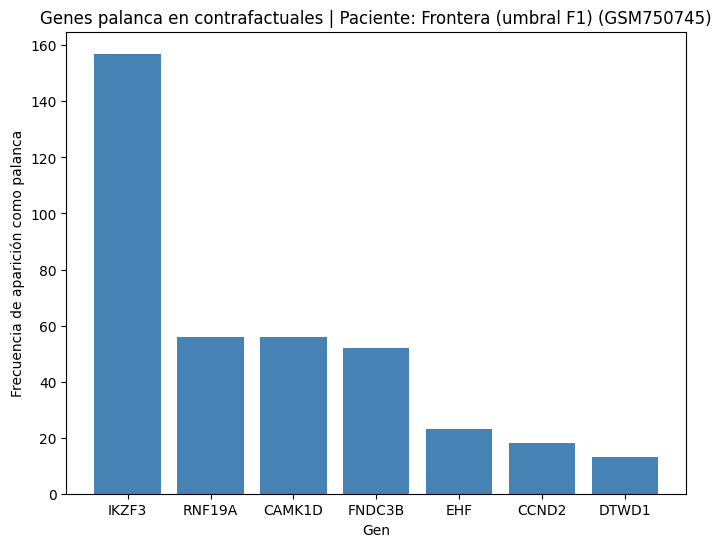

In [92]:
# Cálculo de DiCe y gráfico de barras con genes palanca
# Paciente Frontera
calculate_dice_bootstrap_configured(X_test, y_test, features_to_vary, df_poi_patient.iloc[2])

**Conclusiones extraídas**

En el análisis de contrafactuales y bootstrapping se observa que ciertos genes aparecen de manera consistente como determinantes en la clasificación del modelo. En el paciente positivo claro (GSM158222), los contrafactuales muestran modificaciones recurrentes en CCND2 y FNDC3B, y el bootstrapping confirma esta tendencia con frecuencias de 107 y 108 apariciones respectivamente sobre 150 iteraciones, lo que supone más del 70% de los casos. De forma similar, EHF y RNF19A alcanzan valores cercanos a 90–95 apariciones, consolidando su papel como biomarcadores relevantes en la transición de positivo a negativo.

En el paciente negativo claro (GSM505587), la evidencia es aún más marcada: RNF19A y FNDC3B aparecen en prácticamente todos los contrafactuales, con frecuencias de 248 y 243 sobre 250, es decir, más del 95% de las iteraciones. Además, CAMK1D y IKZF3 muestran también una presencia elevada (180 y 171 apariciones), lo que indica que la activación de estos genes es crítica para revertir la condición negativa. En contraste, genes como CDK6 o DTWD1 apenas aparecen (5 y 1 veces), lo que sugiere un papel marginal en la decisión del modelo.

Finalmente, en el paciente frontera (GSM750745) se aprecia mayor heterogeneidad: IKZF3 es el gen más frecuente con 157 apariciones, mientras que RNF19A, CAMK1D y FNDC3B rondan las 50–56 apariciones, y otros como EHF o CCND2 apenas superan la veintena. Esto refleja que en perfiles intermedios la clasificación depende de un conjunto más amplio de genes, sin que haya un único marcador dominante. En conjunto, los resultados apuntan a CCND2, FNDC3B, RNF19A, CAMK1D e IKZF3 como candidatos robustos a biomarcadores genéticos, con distinta relevancia según el perfil del paciente, lo que aporta una base sólida para su consideración en el contexto del TFG.

### 6. Bootstrap final de cierre

**Objetivo**: Consolidar todo el pipeline y validar robustez global.

*Bootstrap*: Calcular presencia en top‑k y estabilidad de pares en remuestreo.